# Information-Driven Bars: Formulas and Parameter Study

**Chapter 3: Market Microstructure**

**Docker image**: `ml4t`

## Purpose

Two-part validation of imbalance-bar construction: (1) verify the AFML
tick-imbalance formula matches the `ml4t.engineer.bars` library exactly on
DataBento NVDA trades, and (2) sweep $\alpha$ and the target $E[T]$ across
three families (alpha-based EWMA, fixed threshold, rolling window) to expose
the parameter-instability issue that §3.4 warns about.

## Learning Objectives

After completing this notebook, you will be able to:
- State the tick-imbalance threshold formula
  $\theta = \sum b_t$, $E[\theta_T] = E[T] \cdot |2P[b=1] - 1|$
  and the volume-imbalance variant.
- Compare alpha-based, fixed-threshold, and rolling-window imbalance bars,
  and recognize when the alpha-based scheme drifts (e.g., $\alpha=0.1$
  produces ~17x E[T] inflation on liquid equities).
- Choose imbalance-bar parameters that yield well-behaved
  Jarque-Bera / variance-ratio diagnostics.

## Book reference

Section §3.4, *The Art of Sampling* — information-driven-bars subsection.

## Prerequisites

- DataBento XNAS-ITCH MBO parquets at
  `data/equities/market/microstructure/market_by_order/NVDA/`.

In [1]:
"""Information-Driven Bars: Formulas and Parameter Study — verifying AFML imbalance bar formulas and exploring parameter sensitivity."""

import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots
from scipy import stats

# Import loader for MBO data
from data import load_mbo_data

# Polars display configuration

In [2]:
MAX_DAYS = 3

In [3]:
# Get file paths from the canonical loader (handles legacy/new path resolution)
data_files = load_mbo_data(symbols=["NVDA"], list_files=True)
DATABENTO_DIR = data_files[0].parent if data_files else None

### Load Trade Data
Extract and filter trade records from multi-day MBO parquet files.

In [4]:
def load_trades(data_dir: Path, max_days: int = 10) -> tuple[pl.DataFrame | None, list[str]]:
    """Load trade data from multiple days."""
    data_files = sorted(data_dir.glob("*.parquet"))[:max_days]
    if not data_files:
        return None, []

    all_trades = []
    dates = []

    for file_path in data_files:
        date_str = file_path.name.split("-")[2].split(".")[0]
        trade_date = f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:8]}"
        dates.append(trade_date)

        df = pl.read_parquet(file_path)
        ts_col = "ts_event" if "ts_event" in df.columns else "ts_recv"
        df = df.select([ts_col, "action", "side", "price", "size"])
        df = df.with_columns(pl.col(ts_col).cast(pl.Datetime("ns")).alias("timestamp"))
        df = df.filter(pl.col("action") == "T")
        # Filter to trading hours (9:30-16:00 ET)
        # Note: This uses 13:30-21:00 UTC which covers both EDT (summer) and EST (winter).
        # The conservative filter may include 15-30 min of pre/post market data depending
        # on season. A robust solution would convert to America/New_York first.
        df = df.filter(
            (
                (pl.col("timestamp").dt.hour() > 13)
                | ((pl.col("timestamp").dt.hour() == 13) & (pl.col("timestamp").dt.minute() >= 30))
            )
            & (pl.col("timestamp").dt.hour() < 21)
        )
        df = df.with_columns(
            pl.when(pl.col("side") == "A")
            .then(1)
            .when(pl.col("side") == "B")
            .then(-1)
            .otherwise(0)
            .alias("side_num")
        )
        df = df.select(
            [
                "timestamp",
                pl.col("price"),
                pl.col("size").alias("volume"),
                pl.col("side_num").alias("side"),
            ]
        ).sort("timestamp")
        all_trades.append(df)

    return pl.concat(all_trades), dates

In [5]:
# Load data
trades, dates = load_trades(DATABENTO_DIR, max_days=MAX_DAYS)

if trades is None or len(trades) == 0:
    raise FileNotFoundError(
        "Missing DataBento MBO trade data for NVDA. "
        "Expected parquet files under data/equities/market_by_order/NVDA."
    )

trades = trades.filter(pl.col("side") != 0)
print(f"Loaded {len(trades):,} trades from {len(dates)} days")
print(f"Date range: {dates[0]} to {dates[-1]}")
print(f"Buy fraction: {(trades['side'] > 0).mean():.2%}")

Loaded 574,742 trades from 3 days
Date range: 2024-11-04 to 2024-11-06
Buy fraction: 47.30%


## 2. Formula Verification: Manual vs Library

We implement tick imbalance bars manually to verify the library is correct.

In [6]:
def calculate_tick_imbalance_bars_manual(
    sides: np.ndarray,
    expected_t: float = 1000.0,
    alpha: float = 0.1,
    min_bars_warmup: int = 10,
) -> tuple[list[int], list[dict]]:
    """
    Manual AFML tick imbalance bars.

    θ = Σ b_t (cumulative signed ticks)
    E[θ_T] = E[T] × |2P[b=1] - 1|
    """
    n = len(sides)

    # Initialize from warmup (matches library)
    warmup_size = min(1000, n)
    p_buy = float(np.mean(sides[:warmup_size] > 0))

    bar_indices = []
    bar_info = []

    cumulative_theta = 0.0
    bar_tick_count = 0
    bar_buy_count = 0
    n_bars = 0

    for i in range(n):
        side = sides[i]
        is_buy = side > 0

        cumulative_theta += side
        bar_tick_count += 1
        if is_buy:
            bar_buy_count += 1

        # AFML threshold
        threshold = expected_t * abs(2 * p_buy - 1)

        if abs(cumulative_theta) >= threshold:
            bar_indices.append(i)
            bar_info.append(
                {
                    "bar": n_bars,
                    "ticks": bar_tick_count,
                    "theta": cumulative_theta,
                    "threshold": threshold,
                    "E[T]": expected_t,
                    "P[b=1]": p_buy,
                }
            )

            n_bars += 1

            # Update EWMA after warmup
            if n_bars > min_bars_warmup:
                expected_t = alpha * bar_tick_count + (1 - alpha) * expected_t
                bar_p_buy = bar_buy_count / bar_tick_count
                p_buy = alpha * bar_p_buy + (1 - alpha) * p_buy

            # Reset
            cumulative_theta = 0.0
            bar_tick_count = 0
            bar_buy_count = 0

    return bar_indices, bar_info

In [7]:
# Run manual calculation
# Use slow adaptation to prevent threshold spiral
sides_arr = trades["side"].to_numpy()
VERIFY_ET = 1000
VERIFY_ALPHA = 0.001
VERIFY_WARMUP = 100

manual_indices, manual_info = calculate_tick_imbalance_bars_manual(
    sides_arr, expected_t=VERIFY_ET, alpha=VERIFY_ALPHA, min_bars_warmup=VERIFY_WARMUP
)
print(f"Manual TIB calculation: {len(manual_indices)} bars")

Manual TIB calculation: 594 bars


In [8]:
# Compare with library
from ml4t.engineer.bars import TickImbalanceBarSampler

sampler = TickImbalanceBarSampler(
    expected_ticks_per_bar=VERIFY_ET,
    alpha=VERIFY_ALPHA,
    min_bars_warmup=VERIFY_WARMUP,
)
library_bars = sampler.sample(trades)
print(f"Library TIB calculation: {len(library_bars)} bars")

# Verify match
if len(manual_indices) == len(library_bars):
    manual_thresholds = [d["threshold"] for d in manual_info]
    library_thresholds = library_bars["expected_imbalance"].to_list()
    max_diff = max(
        abs(m - lib) for m, lib in zip(manual_thresholds, library_thresholds, strict=False)
    )
    print(f"Max threshold difference: {max_diff:.6f}")
    print("[OK] Manual and library match!")
else:
    print("[FAIL] Bar counts differ")

# Show first few bars
print("\nFirst 5 bars:")
pl.DataFrame(manual_info[:5])

Library TIB calculation: 594 bars
Max threshold difference: 0.000000
[OK] Manual and library match!

First 5 bars:


bar,ticks,theta,threshold,E[T],P[b=1]
i64,i64,f64,f64,i64,f64
0,971,-157.0,156.0,1000,0.422
1,1159,157.0,156.0,1000,0.422
2,2109,-157.0,156.0,1000,0.422
3,589,-157.0,156.0,1000,0.422
4,221,-157.0,156.0,1000,0.422


## 3. Parameter Study Using Library

Now we use the faster library implementation to study how E[T] affects properties.

**Statistical Metrics Explained**:
- **Jarque-Bera (JB)**: Tests normality. Lower = more normal (JB=0 is perfectly normal).
  High JB indicates fat tails/skewness.
- **Autocorrelation(1)**: Correlation of returns with 1-bar-lagged returns.
  Should be ~0 for efficient markets.
- **Variance Ratio(5)**: Var(5-bar returns) / (5 × Var(1-bar returns)).
  Should be ~1 for random walk. >1 = momentum, <1 = mean reversion.

In [9]:
from ml4t.engineer.bars import ImbalanceBarSampler, TickImbalanceBarSampler


def compute_stats(bars: pl.DataFrame) -> dict:
    """Compute statistical properties of bar returns."""
    if len(bars) < 30:
        return {
            "n_bars": len(bars),
            "jarque_bera": np.nan,
            "autocorr_1": np.nan,
            "variance_ratio_5": np.nan,
        }

    returns = bars["close"].pct_change().drop_nulls().to_numpy()
    returns = returns[np.isfinite(returns)]
    if len(returns) < 10:
        return {
            "n_bars": len(bars),
            "jarque_bera": np.nan,
            "autocorr_1": np.nan,
            "variance_ratio_5": np.nan,
        }

    jb, _ = stats.jarque_bera(returns)
    ac = np.corrcoef(returns[:-1], returns[1:])[0, 1] if len(returns) > 1 else np.nan

    if len(returns) > 5:
        var_1 = np.var(returns)
        summed = np.array([np.sum(returns[i : i + 5]) for i in range(len(returns) - 4)])
        var_5 = np.var(summed) / 5
        vr = var_5 / var_1 if var_1 > 0 else np.nan
    else:
        vr = np.nan

    return {"n_bars": len(bars), "jarque_bera": jb, "autocorr_1": ac, "variance_ratio_5": vr}

In [10]:
# Parameter grids
# Key insight: with persistent order flow imbalance, need SLOW adaptation (α=0.001)
# to prevent threshold spiral. Also use longer warmup.
TIB_ET = [500, 700, 1000, 1500, 2000, 3000]
VIB_ET = [2000, 5000, 10000, 20000, 50000]
ALPHA = 0.001  # Very slow adaptation - critical for stability
WARMUP = 100  # Longer warmup

print("=" * 70)
print("TICK IMBALANCE BARS (TIBs) - alpha=0.001, warmup=100")
print("=" * 70)
tib_results = []
for et in TIB_ET:
    bars = TickImbalanceBarSampler(
        expected_ticks_per_bar=et, alpha=ALPHA, min_bars_warmup=WARMUP
    ).sample(trades)
    s = compute_stats(bars)
    s["expected_t"] = et
    tib_results.append(s)
    print(
        f"E[T]={et:>6}: {s['n_bars']:>5} bars, JB={s['jarque_bera']:>8.1f}, "
        f"AC(1)={s['autocorr_1']:>6.3f}, VR(5)={s['variance_ratio_5']:>5.2f}"
    )

print("\n" + "=" * 70)
print("VOLUME IMBALANCE BARS (VIBs) - alpha=0.001, warmup=100")
print("=" * 70)
vib_results = []
for et in VIB_ET:
    bars = ImbalanceBarSampler(
        expected_ticks_per_bar=et, alpha=ALPHA, min_bars_warmup=WARMUP
    ).sample(trades)
    s = compute_stats(bars)
    s["expected_t"] = et
    vib_results.append(s)
    print(
        f"E[T]={et:>6}: {s['n_bars']:>5} bars, JB={s['jarque_bera']:>8.1f}, "
        f"AC(1)={s['autocorr_1']:>6.3f}, VR(5)={s['variance_ratio_5']:>5.2f}"
    )

TICK IMBALANCE BARS (TIBs) - alpha=0.001, warmup=100
E[T]=   500:  2494 bars, JB=323143.5, AC(1)=-0.013, VR(5)= 0.94
E[T]=   700:   969 bars, JB= 16017.1, AC(1)= 0.013, VR(5)= 1.07
E[T]=  1000:   594 bars, JB= 48722.0, AC(1)= 0.039, VR(5)= 1.10
E[T]=  1500:   358 bars, JB= 22030.4, AC(1)=-0.031, VR(5)= 1.07
E[T]=  2000:   263 bars, JB= 12845.7, AC(1)= 0.055, VR(5)= 1.17
E[T]=  3000:   159 bars, JB=  2080.2, AC(1)= 0.068, VR(5)= 0.94

VOLUME IMBALANCE BARS (VIBs) - alpha=0.001, warmup=100


E[T]=  2000:   503 bars, JB= 24170.6, AC(1)= 0.064, VR(5)= 1.21
E[T]=  5000:   279 bars, JB=  5544.0, AC(1)= 0.044, VR(5)= 1.07
E[T]= 10000:    87 bars, JB=   261.2, AC(1)=-0.054, VR(5)= 0.67
E[T]= 20000:    36 bars, JB=    61.7, AC(1)=-0.032, VR(5)= 0.71
E[T]= 50000:    12 bars, JB=     nan, AC(1)=   nan, VR(5)=  nan


## 4. Visualize Results

In [11]:
tib_df = pl.DataFrame(tib_results)
vib_df = pl.DataFrame(vib_results)

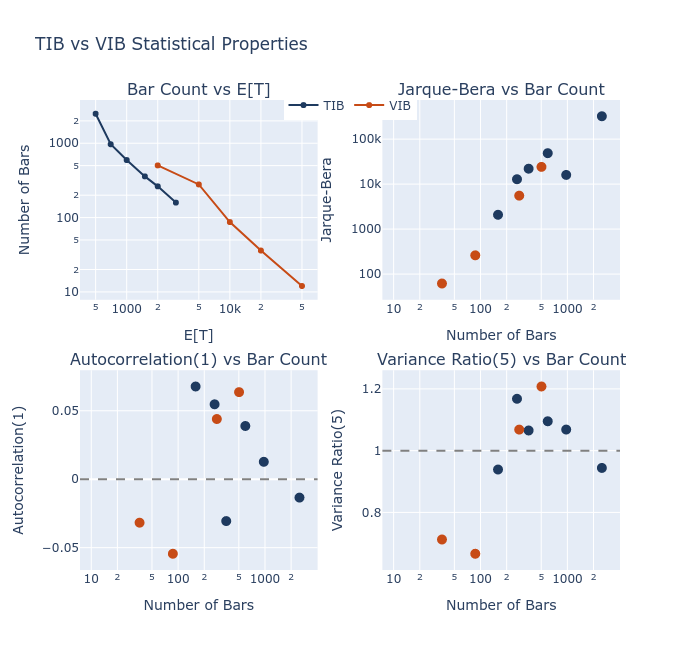

In [12]:
# Construct all four panels and show the figure exactly once to avoid
# matplotlib/plotly intermediate-cell renders of an incomplete figure.
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[
        "Bar Count vs E[T]",
        "Jarque-Bera vs Bar Count",
        "Autocorrelation(1) vs Bar Count",
        "Variance Ratio(5) vs Bar Count",
    ],
    vertical_spacing=0.15,
    horizontal_spacing=0.12,
)

tib_color, vib_color = "#1e3a5f", "#c74b16"

# Panel 1: bar count vs E[T]
for name, color, df in [("TIB", tib_color, tib_df), ("VIB", vib_color, vib_df)]:
    fig.add_trace(
        go.Scatter(
            x=df["expected_t"].to_list(),
            y=df["n_bars"].to_list(),
            mode="lines+markers",
            name=name,
            line=dict(color=color),
        ),
        row=1,
        col=1,
    )
fig.update_xaxes(type="log", title_text="E[T]", row=1, col=1)
fig.update_yaxes(type="log", title_text="Number of Bars", row=1, col=1)

# Panel 2: Jarque-Bera vs bar count
for name, color, df in [("TIB", tib_color, tib_df), ("VIB", vib_color, vib_df)]:
    fig.add_trace(
        go.Scatter(
            x=df["n_bars"].to_list(),
            y=df["jarque_bera"].to_list(),
            mode="markers",
            marker=dict(color=color, size=10),
            showlegend=False,
        ),
        row=1,
        col=2,
    )
fig.update_xaxes(type="log", title_text="Number of Bars", row=1, col=2)
fig.update_yaxes(type="log", title_text="Jarque-Bera", row=1, col=2)

# Panel 3: autocorrelation(1) vs bar count
for name, color, df in [("TIB", tib_color, tib_df), ("VIB", vib_color, vib_df)]:
    fig.add_trace(
        go.Scatter(
            x=df["n_bars"].to_list(),
            y=df["autocorr_1"].to_list(),
            mode="markers",
            marker=dict(color=color, size=10),
            showlegend=False,
        ),
        row=2,
        col=1,
    )
fig.add_hline(y=0, line_dash="dash", line_color="gray", row=2, col=1)
fig.update_xaxes(type="log", title_text="Number of Bars", row=2, col=1)
fig.update_yaxes(title_text="Autocorrelation(1)", row=2, col=1)

# Panel 4: variance ratio(5) vs bar count
for name, color, df in [("TIB", tib_color, tib_df), ("VIB", vib_color, vib_df)]:
    fig.add_trace(
        go.Scatter(
            x=df["n_bars"].to_list(),
            y=df["variance_ratio_5"].to_list(),
            mode="markers",
            marker=dict(color=color, size=10),
            showlegend=False,
        ),
        row=2,
        col=2,
    )
fig.add_hline(y=1, line_dash="dash", line_color="gray", row=2, col=2)
fig.update_xaxes(type="log", title_text="Number of Bars", row=2, col=2)
fig.update_yaxes(title_text="Variance Ratio(5)", row=2, col=2)

fig.update_layout(
    title="TIB vs VIB Statistical Properties",
    height=650,
    legend=dict(x=0.5, y=1.02, xanchor="center", orientation="h"),
)
fig.show()

## 5. Key Takeaways

| Property | TIBs | VIBs |
|----------|------|------|
| Accumulates | Trade signs (+1/-1) | Signed volume |
| Threshold scale | ~0.2 × E[T] | ~800 × E[T] |
| Bars for same E[T] | Many more | Far fewer |

### Critical Calibration Insight

With persistent order flow imbalance (common in real data), the adaptive EWMA
can cause **threshold spiral** - bars get progressively larger as the algorithm
adapts E[T] and P[b=1] upward.

**Solution**: Use very slow adaptation:
- α = 0.001 (not 0.1)
- warmup = 100+ bars (not 10)

### AFML Insight

There's no "optimal" E[T]. Choose based on:
- Desired bar frequency (more bars = better normality, but more noise)
- Trading horizon (intraday needs more bars than swing)
- Signal strength vs statistical properties tradeoff

## 6. Comparing Three Approaches: α-Based, Fixed, and Window-Based

The ml4t-engineer library provides three different implementations:

1. **α-Based (AFML)**: Exponential decay for E[T] and P[b=1] - requires careful α tuning
2. **Fixed Threshold**: No adaptation - simplest and most predictable
3. **Window-Based**: Rolling window adaptation - bounded drift

Let's compare them on the same data.

In [13]:
from ml4t.engineer.bars import (
    FixedTickImbalanceBarSampler,  # Fixed threshold
    TickImbalanceBarSampler,  # α-based
    WindowTickImbalanceBarSampler,  # Window-based
)

# Test parameters - match the handoff comparison
COMPARE_ET = 1000
COMPARE_THRESHOLD = 100  # For fixed


# Track how E[T] drifts for each method
def measure_et_drift(bars: pl.DataFrame) -> float:
    """Measure E[T] drift (last / first expected_t)."""
    if "expected_t" not in bars.columns or len(bars) == 0:
        return 1.0  # No drift for fixed or empty bars
    first = bars["expected_t"][0]
    last = bars["expected_t"][-1]
    return last / first if first > 0 else 1.0

In [14]:
print("=" * 70)
print("COMPARING THREE TICK IMBALANCE BAR APPROACHES")
print("=" * 70)

comparison = []

# 1. α-based with different alphas
for alpha in [0.001, 0.01, 0.1]:
    bars = TickImbalanceBarSampler(
        expected_ticks_per_bar=COMPARE_ET,
        alpha=alpha,
        min_bars_warmup=100,
    ).sample(trades)
    drift = measure_et_drift(bars)
    bar_stats = compute_stats(bars)
    comparison.append(
        {
            "method": f"α={alpha}",
            "n_bars": len(bars),
            "avg_ticks": len(trades) / len(bars) if len(bars) > 0 else 0,
            "et_drift": drift,
            "jb": bar_stats["jarque_bera"],
            "ac1": bar_stats["autocorr_1"],
        }
    )
    print(
        f"α-based α={alpha}: {len(bars):>4} bars, "
        f"avg_ticks={len(trades) / len(bars) if len(bars) > 0 else 0:>7.0f}, E[T] drift={drift:.2f}x"
    )

COMPARING THREE TICK IMBALANCE BAR APPROACHES
α-based α=0.001:  594 bars, avg_ticks=    968, E[T] drift=0.98x


α-based α=0.01: 399507 bars, avg_ticks=      1, E[T] drift=0.00x
α-based α=0.1:  169 bars, avg_ticks=   3401, E[T] drift=17.53x


In [15]:
# 2. Fixed threshold
for thresh in [50, 100, 200]:
    bars = FixedTickImbalanceBarSampler(threshold=thresh).sample(trades)
    bar_stats = compute_stats(bars)
    comparison.append(
        {
            "method": f"fixed={thresh}",
            "n_bars": len(bars),
            "avg_ticks": len(trades) / len(bars) if len(bars) > 0 else 0,
            "et_drift": 1.0,
            "jb": bar_stats["jarque_bera"],
            "ac1": bar_stats["autocorr_1"],
        }
    )
    print(
        f"Fixed thresh={thresh}: {len(bars):>4} bars, "
        f"avg_ticks={len(trades) / len(bars) if len(bars) > 0 else 0:>7.0f}, E[T] drift=N/A"
    )

Fixed thresh=50: 3061 bars, avg_ticks=    188, E[T] drift=N/A
Fixed thresh=100: 1189 bars, avg_ticks=    483, E[T] drift=N/A
Fixed thresh=200:  488 bars, avg_ticks=   1178, E[T] drift=N/A


In [16]:
# 3. Window-based with different tick windows
for tick_win in [2000, 5000, 10000]:
    bars = WindowTickImbalanceBarSampler(
        initial_expected_t=COMPARE_ET,
        bar_window=10,
        tick_window=tick_win,
    ).sample(trades)
    drift = measure_et_drift(bars)
    bar_stats = compute_stats(bars)
    comparison.append(
        {
            "method": f"window={tick_win}",
            "n_bars": len(bars),
            "avg_ticks": len(trades) / len(bars) if len(bars) > 0 else 0,
            "et_drift": drift,
            "jb": bar_stats["jarque_bera"],
            "ac1": bar_stats["autocorr_1"],
        }
    )
    print(
        f"Window tick_win={tick_win}: {len(bars):>4} bars, "
        f"avg_ticks={len(trades) / len(bars) if len(bars) > 0 else 0:>7.0f}, E[T] drift={drift:.2f}x"
    )

Window tick_win=2000: 571536 bars, avg_ticks=      1, E[T] drift=0.00x


Window tick_win=5000: 568745 bars, avg_ticks=      1, E[T] drift=0.00x


Window tick_win=10000: 564313 bars, avg_ticks=      1, E[T] drift=0.00x


In [17]:
# Summary table
compare_df = pl.DataFrame(comparison)
print("\n" + "=" * 70)
print("COMPARISON SUMMARY")
print("=" * 70)
compare_df = compare_df.with_columns(
    [
        pl.col("avg_ticks").round(0).cast(pl.Int64),
        pl.col("et_drift").round(2),
        pl.col("jb").round(1),
        pl.col("ac1").round(3),
    ]
)
print(compare_df)


COMPARISON SUMMARY
shape: (9, 6)
┌──────────────┬────────┬───────────┬──────────┬───────────┬────────┐
│ method       ┆ n_bars ┆ avg_ticks ┆ et_drift ┆ jb        ┆ ac1    │
│ ---          ┆ ---    ┆ ---       ┆ ---      ┆ ---       ┆ ---    │
│ str          ┆ i64    ┆ i64       ┆ f64      ┆ f64       ┆ f64    │
╞══════════════╪════════╪═══════════╪══════════╪═══════════╪════════╡
│ α=0.001      ┆ 594    ┆ 968       ┆ 0.98     ┆ 48722.0   ┆ 0.039  │
│ α=0.01       ┆ 399507 ┆ 1         ┆ 0.0      ┆ 1.3300e12 ┆ -0.03  │
│ α=0.1        ┆ 169    ┆ 3401      ┆ 17.53    ┆ 16329.7   ┆ 0.068  │
│ fixed=50     ┆ 3061   ┆ 188       ┆ 1.0      ┆ 399743.7  ┆ -0.009 │
│ fixed=100    ┆ 1189   ┆ 483       ┆ 1.0      ┆ 32270.0   ┆ 0.013  │
│ fixed=200    ┆ 488    ┆ 1178      ┆ 1.0      ┆ 30510.9   ┆ 0.085  │
│ window=2000  ┆ 571536 ┆ 1         ┆ 0.0      ┆ 3.2633e12 ┆ -0.022 │
│ window=5000  ┆ 568745 ┆ 1         ┆ 0.0      ┆ 3.8027e12 ┆ -0.016 │
│ window=10000 ┆ 564313 ┆ 1         ┆ 0.0      ┆ 4.0673e

## 7. Recommendations

| Use Case | Recommended Method | Why |
|----------|-------------------|-----|
| Production | `FixedTickImbalanceBarSampler` | Simplest, no drift, predictable |
| Research | `TickImbalanceBarSampler(α=0.001)` | Closest to textbook, slow adaptation |

**Key Findings**:
- The adaptive α-scheme fails in two opposite ways here: α=0.01 collapses the
  threshold (399,507 bars, avg 1 tick/bar), while α=0.1 inflates it (169 bars,
  avg 3,401 ticks/bar, ~17.5x E[T] drift). Only α=0.001 stays near target
  (594 bars, avg 968 ticks/bar, ~1x drift).
- The window-based sampler also produces degenerate bars in this test — likely a
  parameterization or implementation issue to investigate further
- α=0.001 with warmup=100 and fixed thresholds are the only reliable approaches here

In [18]:
print("\n" + "=" * 70)
print("NOTEBOOK SUMMARY")
print("=" * 70)
print("\nTIBs:")
print(tib_df.select(["expected_t", "n_bars", "jarque_bera", "autocorr_1", "variance_ratio_5"]))
print("\nVIBs:")
print(vib_df.select(["expected_t", "n_bars", "jarque_bera", "autocorr_1", "variance_ratio_5"]))
print("\nThree-Approach Comparison:")
print(compare_df)
print("\nNotebook completed.")


NOTEBOOK SUMMARY

TIBs:
shape: (6, 5)
┌────────────┬────────┬───────────────┬────────────┬──────────────────┐
│ expected_t ┆ n_bars ┆ jarque_bera   ┆ autocorr_1 ┆ variance_ratio_5 │
│ ---        ┆ ---    ┆ ---           ┆ ---        ┆ ---              │
│ i64        ┆ i64    ┆ f64           ┆ f64        ┆ f64              │
╞════════════╪════════╪═══════════════╪════════════╪══════════════════╡
│ 500        ┆ 2494   ┆ 323143.493087 ┆ -0.013431  ┆ 0.944036         │
│ 700        ┆ 969    ┆ 16017.093229  ┆ 0.012707   ┆ 1.068278         │
│ 1000       ┆ 594    ┆ 48721.989791  ┆ 0.038874   ┆ 1.095136         │
│ 1500       ┆ 358    ┆ 22030.445685  ┆ -0.030572  ┆ 1.065303         │
│ 2000       ┆ 263    ┆ 12845.736803  ┆ 0.054711   ┆ 1.167906         │
│ 3000       ┆ 159    ┆ 2080.242665   ┆ 0.067727   ┆ 0.938884         │
└────────────┴────────┴───────────────┴────────────┴──────────────────┘

VIBs:
shape: (5, 5)
┌────────────┬────────┬──────────────┬────────────┬──────────────────┐
│ exp